# Celebrity Image Classification using CNN

In [1]:
import warnings
warnings.filterwarnings("ignore")

Import Required Libraries

In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import load_model

Load Trained CNN Model

In [3]:
model = load_model("sports_person_model.h5")

print("Model Loaded Successfully!")

Model Loaded Successfully!


Define Class Labels

In [22]:
class_names = {
    0: "Lionel Messi",
    1: "Maria Sharapova",
    2: "Roger Federer",
    3: "Serena Williams",
    4: "Virat Kohli"
}

Load Test Image

In [23]:
image_path = "virat.jpg"

img = cv2.imread(image_path)

# Check if image is loaded
if img is None:
    print("Error: Image not found!")
else:
    print("Image Loaded Successfully!")

# Convert BGR to RGB
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

Image Loaded Successfully!


 Display Original Image

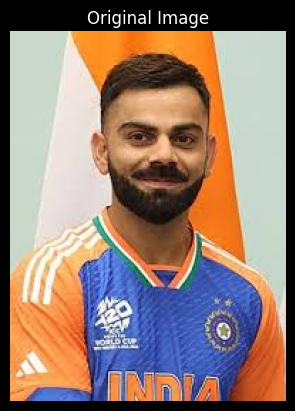

In [24]:
plt.imshow(img_rgb)
plt.title("Original Image")
plt.axis("off")
plt.show()

Resize and Preprocess Image

In [25]:
print(model.input_shape)

(None, 150, 150, 3)


In [26]:
# Resize image to model input size
img_resized = cv2.resize(img_rgb, (150, 150))

# Convert image to array
img_array = np.array(img_resized)

# Normalize
img_array = img_array / 255.0

# Add batch dimension
img_array = np.expand_dims(img_array, axis=0)
print("Image Shape:", img_array.shape)


Image Shape: (1, 150, 150, 3)


Predict Celebrity

In [27]:
# Predict
prediction = model.predict(img_array)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step


In [28]:
# Get predicted class
predicted_class = np.argmax(prediction)

# Class labels
celebrity_name = class_names[predicted_class]

confidence = np.max(prediction) * 100
print("Predicted Celebrity:", celebrity_name)
print(f"Confidence: {confidence:.2f}%")

Predicted Celebrity: Virat Kohli
Confidence: 59.16%


Display Final Result

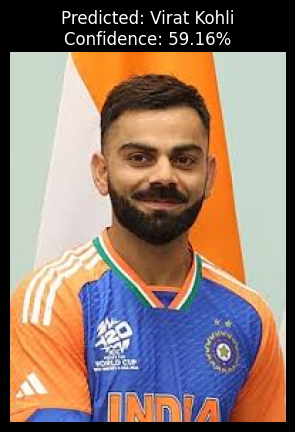

In [29]:
plt.imshow(img_rgb)
plt.title(f"Predicted: {celebrity_name}\nConfidence: {confidence:.2f}%")
plt.axis("off")
plt.show()